In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
sys.path.append('./')  # uncomment for local import
import tangram as tg

%load_ext autoreload
%autoreload 2
%matplotlib inline

tg.__version__

'1.0.4'

In [2]:
#Load spatial
path = os.path.join('./data', 'mLung_O_st.h5ad')
ad_sp = sc.read_h5ad(path)
ad_sp.var

,name
1810065E05Rik,1810065E05Rik
2210010C04Rik,2210010C04Rik
2610528A11Rik,2610528A11Rik
AA467197,AA467197
Abhd12,Abhd12
...,...
Wnt2,Wnt2
Wnt9a,Wnt9a
Xist,Xist
Zg16,Zg16


In [3]:
#Subset objects
specific_value = 'mLung_O1_ST'
ad_sp_subset1 = ad_sp[ad_sp.obs['orig.ident'] == specific_value]
ad_sp_subset1.var

,name
1810065E05Rik,1810065E05Rik
2210010C04Rik,2210010C04Rik
2610528A11Rik,2610528A11Rik
AA467197,AA467197
Abhd12,Abhd12
...,...
Wnt2,Wnt2
Wnt9a,Wnt9a
Xist,Xist
Zg16,Zg16


In [4]:
#Load single cell
path = os.path.join('data','mLung_O_sc.h5ad')
ad_sc = sc.read_h5ad(path)
ad_sc

AnnData object with n_obs × n_vars = 18083 × 20055
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'pANN_0.25_0.25_412', 'DF.classifications_0.25_0.25_412', 'percent.mt', 'pANN_0.25_0.26_453', 'DF.classifications_0.25_0.26_453', 'pANN_0.25_0.19_503', 'DF.classifications_0.25_0.19_503', 'percent.ribo', 'integrated_snn_res.0.8', 'seurat_clusters', 'predicted.id', 'prediction.score.B.cell', 'prediction.score.non.classical.monocyte', 'prediction.score.natural.killer.cell', 'prediction.score.alveolar.macrophage', 'prediction.score.myeloid.dendritic.cell', 'prediction.score.CD8.positive..alpha.beta.T.cell', 'prediction.score.classical.monocyte', 'prediction.score.bronchial.smooth.muscle.cell', 'prediction.score.mature.NK.T.cell', 'prediction.score.T.cell', 'prediction.score.pulmonary.interstitial.fibroblast', 'prediction.score.intermediate.monocyte', 'prediction.score.neutrophil', 'prediction.score.adventitial.cell', 'prediction.score.CD4.positive..alpha.beta.T.cell', 'prediction.score.

In [5]:
#Subset scRNA-seq
specific_value = 'mLung_O1'
ad_sc_subset1 = ad_sc[ad_sc.obs['orig.ident'] == specific_value]
ad_sc_subset1.var

,name
Xkr4,Xkr4
Gm1992,Gm1992
Gm37381,Gm37381
Rp1,Rp1
Sox17,Sox17
...,...
Gm11337,Gm11337
Anxa13,Anxa13
Tmem207,Tmem207
Vmn2r118,Vmn2r118


In [6]:
#Normalize sc
sc.pp.normalize_total(ad_sc_subset1)
#Normalize sp
sc.pp.normalize_total(ad_sp_subset1)
ad_sc_subset1.obs['cell_annotated'].value_counts()

cell_annotated
Alveolar type 2 cell                922
Endothelial cell                    604
Fibroblast                          565
Club cells                          422
Mesenchimal cells                   400
Alveolar type 1 cell                386
Macrophage                          374
B cells                             294
Red blood cells                     229
Smooth muscle cells                 179
Monocytes                           172
Lipofibroblasts                     170
T cells                             169
Ciliated cells                      153
Krt4/Krt13 epithelial cell state     87
Dendritic cells                      79
Goblet cells                         44
Name: count, dtype: int64

In [7]:
#Marker genes for mapping sc to st
df_genes = pd.read_csv('data/gene.csv', index_col=0)
markers = np.reshape(df_genes.values, (-1, ))
markers = list(markers)
len(markers)

890

In [8]:
#Prepare training_genes
tg.pp_adatas(ad_sc_subset1, ad_sp_subset1, genes=markers)

INFO:root:788 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:788 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [9]:
#Order the genes
assert ad_sc_subset1.uns['training_genes'] == ad_sp_subset1.uns['training_genes']

In [10]:
#MApping
ad_map = tg.map_cells_to_space(
    adata_sc=ad_sc_subset1,
    adata_sp=ad_sp_subset1,
    #device='cpu',
    device='cuda:0'
)

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 788 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.101, KL reg: 0.000
Score: 0.674, KL reg: 0.001
Score: 0.687, KL reg: 0.001
Score: 0.691, KL reg: 0.001
Score: 0.693, KL reg: 0.001
Score: 0.694, KL reg: 0.001
Score: 0.694, KL reg: 0.001
Score: 0.695, KL reg: 0.001
Score: 0.695, KL reg: 0.001
Score: 0.695, KL reg: 0.001


INFO:root:Saving results..


In [11]:
#Analysis
tg.project_cell_annotations(ad_map, ad_sp_subset1, annotation='cell_annotated')
annotation_list = list(pd.unique(ad_sc.obs['cell_annotated']))


INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


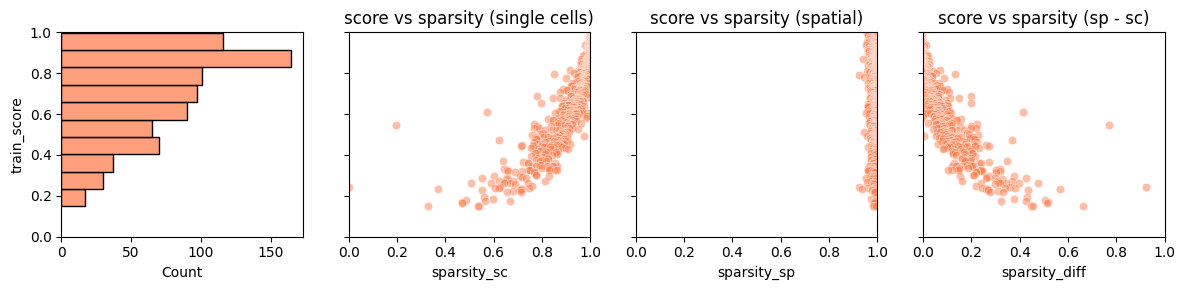

In [12]:
tg.plot_training_scores(ad_map, bins=10, alpha=.5)

In [13]:
ad_ge = tg.project_genes(adata_map=ad_map, adata_sc=ad_sc_subset1)
ad_ge

AnnData object with n_obs × n_vars = 11880 × 19090
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.3', 'seurat_clusters', 'SCT_snn_res.0.5', 'integrated_snn_res.0.4', 'uniform_density', 'rna_count_based_density'
    var: 'name', 'n_cells', 'sparsity', 'is_training'
    uns: 'training_genes', 'overlap_genes'

In [14]:
sc.write("ad_geO1.h5ad", ad_ge)

In [15]:
df_all_genes = tg.compare_spatial_geneexp(ad_ge, ad_sp_subset1, ad_sc_subset1)
df_all_genes

,score,is_training,sparsity_sp,sparsity_sc,sparsity_diff
hmga2,0.564844,True,0.962290,0.999428,-0.037139
cd207,0.388803,True,0.976347,0.999047,-0.022701
itpka,0.381032,True,0.983670,0.983425,0.000245
pcp4l1,0.369439,True,0.967256,0.967232,0.000024
pck1,0.358469,True,0.986279,0.956373,0.029907
...,...,...,...,...,...
rela,0.078227,True,0.991330,0.897695,0.093635
rps15a,0.077980,True,0.992256,0.934654,0.057602
golm1,0.077347,True,0.991835,0.900362,0.091473
gsk3b,0.077268,True,0.992340,0.329396,0.662944


In [16]:
# Check if 'scgb1a1' is in the index of df_all_genes
scgb1a1_gene = df_all_genes.loc['scgb1a1']
scgb1a1_gene

score            0.213714
is_training          True
sparsity_sp      0.967593
sparsity_sc      0.196228
sparsity_diff    0.771365
Name: scgb1a1, dtype: object